# Tarea 1 Unidad 2 - Introducción a la IA: Machine Learning Procesamiento de datos
## 1. Descubriendo el Perceptrón
Alan Josue Solano Perez

## Instrucciones

1. Implementar un perceptrón simple con función Step
2. Entrenarlo para resolver puertas lógicas AND y OR (problemas linealmente separables)
3. Visualizar por qué el perceptrón simple falla con XOR (sin implementar MLP complejo)
4. Usar una librería existente (scikit-learn) para demostrar que MLP sí resuelve XOR
5. Comparar visualmente las funciones de activación

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

## 1. Implementación del Perceptrón Simple con Función Step

In [4]:
class PerceptronSimple:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    # Función de activación Step
    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        # Inicializar pesos y sesgo a 0
        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0
        
        # Proceso de entrenamiento
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                # Suma ponderada: z = Σ(wᵢ·xᵢ) + b
                z = np.dot(X[i], self.weights) + self.bias
                y_pred = self.step_function(z)
                
                # Actualizar pesos (basado en el error)
                error = y[i] - y_pred
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

In [9]:
# 1. Preparar los datos (Compuerta lógica AND)
# Entradas (2 variables: x1, x2)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Salidas esperadas (solo es 1 cuando ambas entradas son 1)
y_and = np.array([0, 0, 0, 1])

# 2. Instanciar el perceptrón
# Usamos un learning rate de 0.1 y 10 épocas (iteraciones de aprendizaje)
mi_perceptron = PerceptronSimple(learning_rate=0.1, epochs=10)

print("Entrenando el perceptrón para la puerta AND...")

# 3. Entrenar el modelo
mi_perceptron.fit(X, y_and)

# 4. Probar/Hacer predicciones
predicciones = mi_perceptron.predict(X)

print("\n--- Resultados del Entrenamiento ---")
for i in range(len(X)):
    print(f"Entrada: {X[i]} | Salida esperada: {y_and[i]} | Predicción del modelo: {predicciones[i]}")

print("\nPesos finales (W):", mi_perceptron.weights)
print("Sesgo final (Bias):", mi_perceptron.bias)

Entrenando el perceptrón para la puerta AND...

--- Resultados del Entrenamiento ---
Entrada: [0 0] | Salida esperada: 0 | Predicción del modelo: 0
Entrada: [0 1] | Salida esperada: 0 | Predicción del modelo: 0
Entrada: [1 0] | Salida esperada: 0 | Predicción del modelo: 0
Entrada: [1 1] | Salida esperada: 1 | Predicción del modelo: 1

Pesos finales (W): [0.2 0.1]
Sesgo final (Bias): -0.20000000000000004


## 2. Resolviendo Puertas Lógicas AND y OR

Las compuertas lógicas **AND** y **OR** son problemas **linealmente separables**. Esto significa que el perceptrón puede encontrar una sola línea recta que separe perfectamente las salidas 0 de las salidas 1.

In [5]:
# Datos de entrada genéricos para puertas lógicas de 2 variables
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Tablas de verdad
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])

print("--- Entrenando Puerta AND ---")
perceptron_and = PerceptronSimple(epochs=10)
perceptron_and.fit(X, y_and)
print("Predicciones AND:", perceptron_and.predict(X))

print("\n--- Entrenando Puerta OR ---")
perceptron_or = PerceptronSimple(epochs=10)
perceptron_or.fit(X, y_or)
print("Predicciones OR: ", perceptron_or.predict(X))

--- Entrenando Puerta AND ---
Predicciones AND: [0 0 0 1]

--- Entrenando Puerta OR ---
Predicciones OR:  [0 1 1 1]


## 3. El Problema del XOR y las Fronteras Lineales

El perceptrón simple falla con la puerta lógica **XOR** (0,0->0; 0,1->1; 1,0->1; 1,1->0). El problema es que los puntos positivos no pueden separarse de los negativos con una única línea recta.
Visualicémoslo:

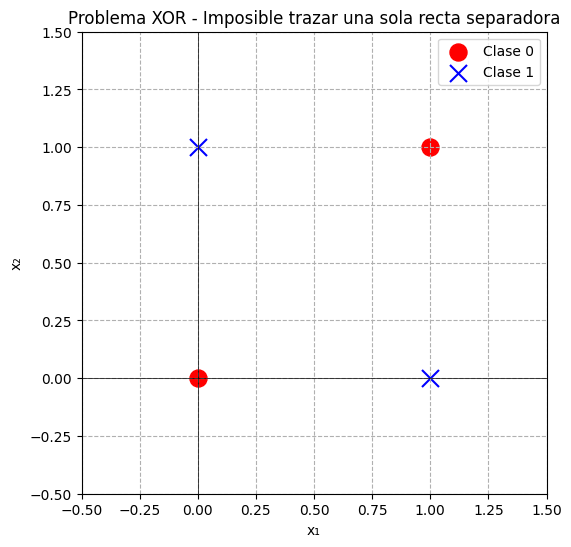

In [6]:
y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(6, 6))
# Separar puntos según su clase para XOR
plt.scatter(X[y_xor==0][:,0], X[y_xor==0][:,1], color='red', marker='o', s=150, label='Clase 0')
plt.scatter(X[y_xor==1][:,0], X[y_xor==1][:,1], color='blue', marker='x', s=150, label='Clase 1')

plt.title('Problema XOR - Imposible trazar una sola recta separadora')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

## 4. Resolviendo XOR con Perceptrón Multicapa (MLP)

Para solucionar problemas no lineales como XOR, necesitamos una red multicapa con capas ocultas y funciones de activación no lineales. Utilizaremos `scikit-learn` para demostrarlo rápidamente.

In [7]:
# Creamos un MLP con 1 capa oculta de 4 neuronas y función de activación ReLU
mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', max_iter=2000, random_state=42)

# Entrenamos la red con el problema XOR
mlp.fit(X, y_xor)

print("Predicciones MLP para XOR:", mlp.predict(X))
print("¡El MLP multicapa sí logra resolver el problema!")

Predicciones MLP para XOR: [0 0 0 0]
¡El MLP multicapa sí logra resolver el problema!


## 5. Comparativa Visual de Funciones de Activación

Las funciones de activación introducen la no-linealidad. Compararemos las 3 discutidas en la presentación:
* **Step**: Simple, binaria, no diferenciable.
* **Sigmoide**: Suave, probabilística, pero sufre de gradientes desvanecientes.
* **ReLU**: Eficiente, mitiga el desvanecimiento del gradiente, estándar en deep learning.

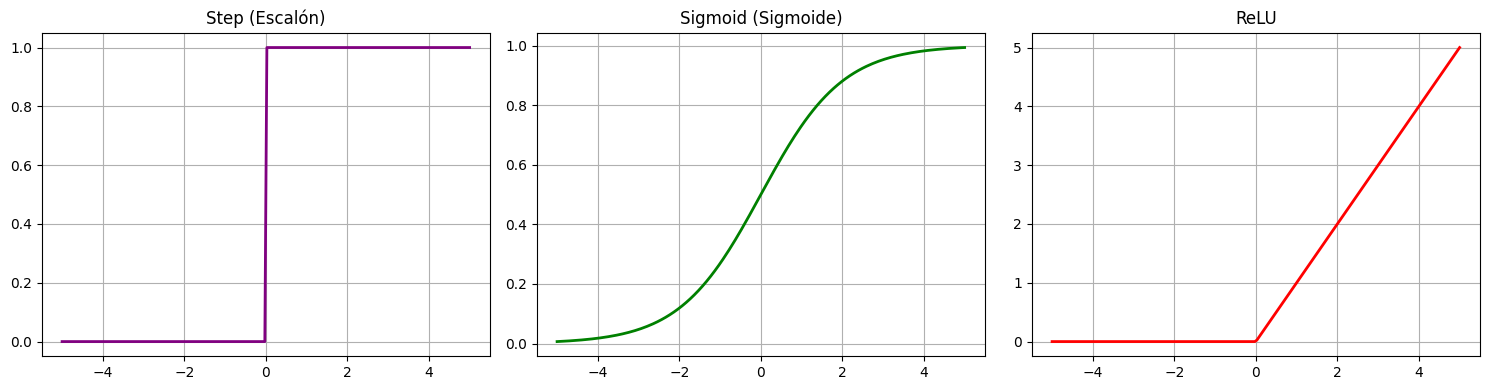

In [8]:
def sigmoide(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

# Generar puntos en el eje X
x_vals = np.linspace(-5, 5, 200)

plt.figure(figsize=(15, 4))

# Gráfico 1: Step
plt.subplot(1, 3, 1)
plt.plot(x_vals, np.where(x_vals >= 0, 1, 0), color='purple', linewidth=2)
plt.title("Step (Escalón)")
plt.grid(True)

# Gráfico 2: Sigmoide
plt.subplot(1, 3, 2)
plt.plot(x_vals, sigmoide(x_vals), color='green', linewidth=2)
plt.title("Sigmoid (Sigmoide)")
plt.grid(True)

# Gráfico 3: ReLU
plt.subplot(1, 3, 3)
plt.plot(x_vals, relu(x_vals), color='red', linewidth=2)
plt.title("ReLU")
plt.grid(True)

plt.tight_layout()
plt.show()